In [1]:
import numpy as np
import sklearn as sk
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [2]:
#Set the default figure size for the notebook, so they are not all tiny
matplotlib.rcParams['figure.figsize'] = (12,8)

In [3]:
def get_data(n):
    K = 3
    #prior probabilities
    pi0 = (.5,.3,.2)
    n_each = [int(n*pi) for pi in pi0]
    #means
    mus = ((0,0),(2,4),(-4,2))
    Sigma = np.matrix(((1,0.5),(0.5,0.9)))*1.6
    
    gaussians = [scipy.stats.multivariate_normal(mean = mus[i],cov = Sigma) for i in range(3)]
        
    X = np.concatenate([gaussian.rvs(n_each[i]) for i, gaussian in enumerate(gaussians)], axis=0)
    y = np.concatenate([np.repeat(i+1,n_each[i]) for i in range(3)])
    
    return({'X':X, 'y':y})


In [4]:
get_data(10)

{'X': array([[ 0.51718909, -0.54791385],
        [ 1.56079495,  1.04740876],
        [ 1.33015735, -0.55227592],
        [ 0.30239504,  1.44988356],
        [ 0.1074297 ,  0.26878181],
        [ 2.19537919,  4.22652368],
        [ 1.98210777,  5.24422405],
        [ 1.24639703,  3.03341028],
        [-4.05145967,  2.22831548],
        [-6.09662263,  1.35057809]]),
 'y': array([1, 1, 1, 1, 1, 2, 2, 2, 3, 3])}

In [5]:
train = get_data(200)
test = get_data(1000)

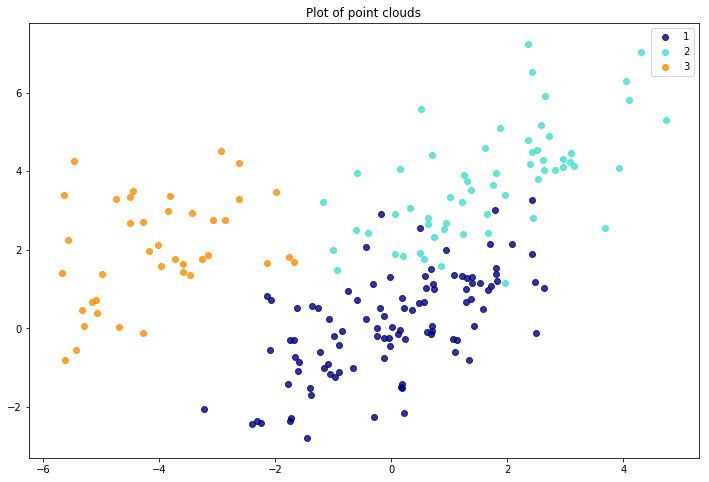

In [6]:
plt.figure()
colors = ['navy', 'turquoise', 'darkorange']

for color, i in zip(colors, [1, 2, 3]):
    plt.scatter(train['X'][train['y'] == i, 0], train['X'][train['y'] == i, 1], color=color, alpha=.8,
                label=str(i))
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('Plot of point clouds')
plt.show()

In [7]:
lda = LinearDiscriminantAnalysis(n_components=2)
fit = lda.fit(train['X'],train['y'])

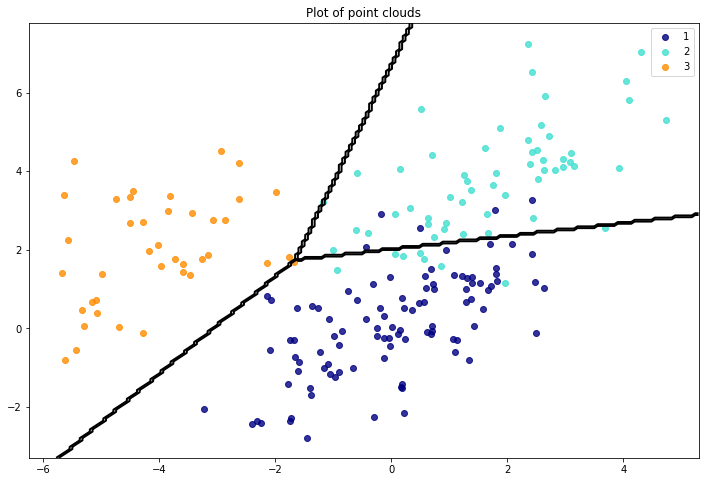

In [8]:

plt.figure()

for color, i in zip(colors, [1, 2, 3]):
    plt.scatter(train['X'][train['y'] == i, 0], train['X'][train['y'] == i, 1], color=color, alpha=.8,
                label=str(i))
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('Plot of point clouds')

#This is a bit of a horrible hack, but I just wanted to make a picture quickly.
#There is certainly a better way...

nx, ny = 200, 200
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                         np.linspace(y_min, y_max, ny))
Z = lda.predict_proba(np.c_[xx.ravel(), yy.ravel()])
#Z = Z[:, 1].reshape(xx.shape)
#plt.pcolormesh(xx, yy, Z, cmap='red_blue_classes',
#                   norm=colors.Normalize(0., 1.))
for i in range(3):
    Z_i = np.where(Z[:, i]== np.max(Z,axis=1),1,0).reshape(xx.shape)
    plt.contour(xx, yy, Z_i, [0.1], linewidths=2., colors='k')

plt.show()

We can also transform into the whitened space

In [9]:
xx.shape
xx[1,1]

-6.1814561887208077

In [10]:
X_lda = fit.transform(train['X'])
zz_lda = fit.transform(np.c_[xx.ravel(), yy.ravel()])
zz_lda.shape

(40000, 2)

In [11]:
zz_lda[:,1]

array([ 4.18942265,  4.17761646,  4.16581028, ..., -4.89398433,
       -4.90579052, -4.91759671])

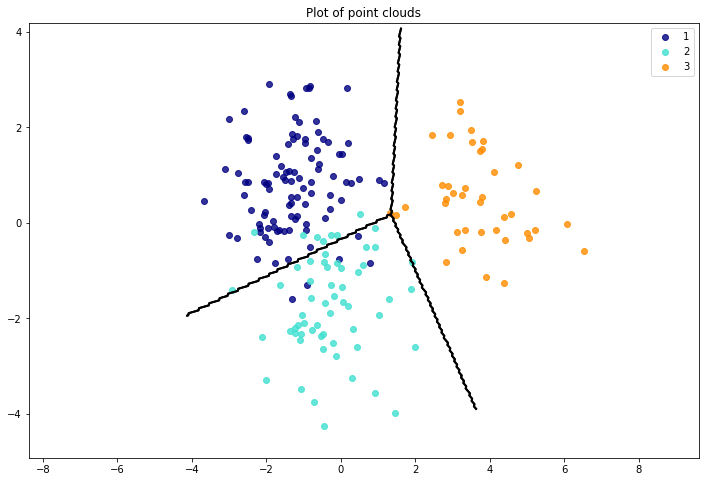

In [12]:

plt.figure()

for color, i in zip(colors, [1, 2, 3]):
    plt.scatter(X_lda[train['y'] == i, 0], X_lda[train['y'] == i, 1], color=color, alpha=.8,
                label=str(i))
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('Plot of point clouds')

#Z = Z[:, 1].reshape(xx.shape)
#plt.pcolormesh(xx, yy, Z, cmap='red_blue_classes',
#                   norm=colors.Normalize(0., 1.))
for i in range(3):
    Z_i = np.where(Z[:, i]== np.max(Z,axis=1),1,0).reshape(xx.shape)
    plt.contour(zz_lda[:,0].reshape(xx.shape), zz_lda[:,1].reshape(xx.shape), Z_i, [0.5], linewidths=2., colors='k')

plt.show()

We can also try QDA

In [13]:
def get_data2(n):
    K = 3
    #prior probabilities
    pi0 = (.5,.3,.2)
    n_each = [int(n*pi) for pi in pi0]
    #means
    mus = ((0,0),(2,4),(-4,2))
    Sigmas = [
        np.matrix(((1,0.8),(0.8,0.9)))*1.6,
        np.matrix(((1,-0.7),(-0.7,0.9)))*1.6,
        np.matrix(((1,0),(0,0.9)))*1
    ]
    
    gaussians = [scipy.stats.multivariate_normal(mean = mus[i],cov = Sigmas[i]) for i in range(3)]
        
    X = np.concatenate([gaussian.rvs(n_each[i]) for i, gaussian in enumerate(gaussians)], axis=0)
    y = np.concatenate([np.repeat(i+1,n_each[i]) for i in range(3)])
    
    return({'X':X, 'y':y})


In [14]:
train = get_data2(200)
test = get_data2(1000)

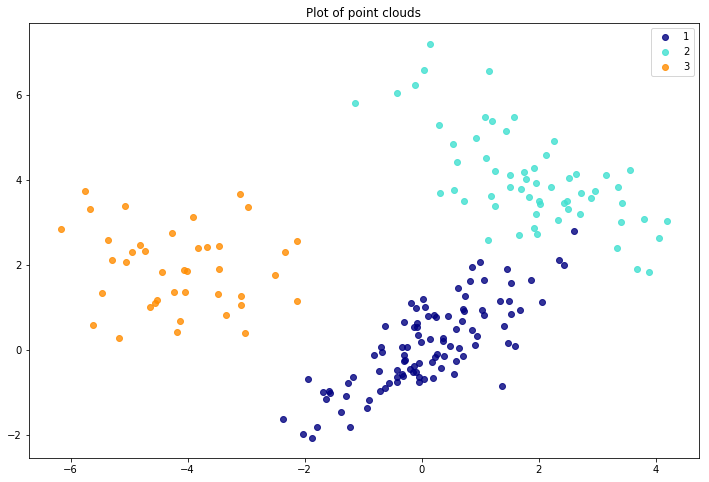

In [15]:
plt.figure()
colors = ['navy', 'turquoise', 'darkorange']

for color, i in zip(colors, [1, 2, 3]):
    plt.scatter(train['X'][train['y'] == i, 0], train['X'][train['y'] == i, 1], color=color, alpha=.8,
                label=str(i))
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('Plot of point clouds')
plt.show()

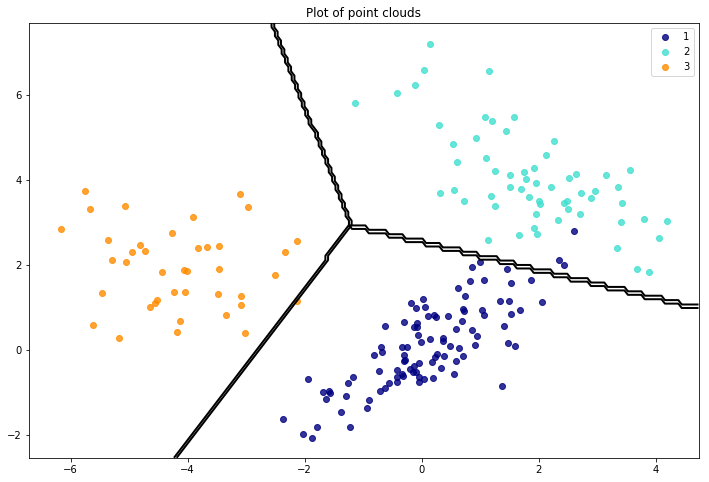

In [16]:
lda = LinearDiscriminantAnalysis(n_components=2)
fit = lda.fit(train['X'],train['y'])

plt.figure()

for color, i in zip(colors, [1, 2, 3]):
    plt.scatter(train['X'][train['y'] == i, 0], train['X'][train['y'] == i, 1], color=color, alpha=.8,
                label=str(i))
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('Plot of point clouds')

#This is a bit of a horrible hack, but I just wanted to make a picture quickly.
#There is certainly a better way...

nx, ny = 200, 100
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                         np.linspace(y_min, y_max, ny))
Z = lda.predict_proba(np.c_[xx.ravel(), yy.ravel()])
#Z = Z[:, 1].reshape(xx.shape)
#plt.pcolormesh(xx, yy, Z, cmap='red_blue_classes',
#                   norm=colors.Normalize(0., 1.))
for i in range(3):
    Z_i = np.where(Z[:, i]== np.max(Z,axis=1),1,0).reshape(xx.shape)
    plt.contour(xx, yy, Z_i, [0.1], linewidths=2., colors='k')

plt.show()

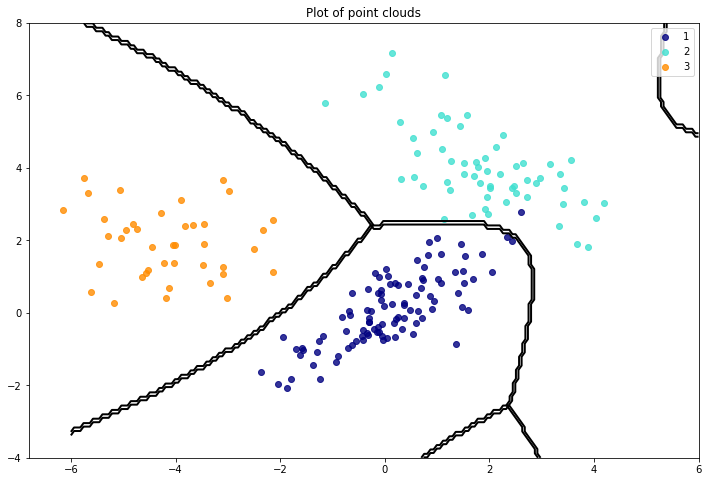

In [18]:
qda = QuadraticDiscriminantAnalysis()
fit = qda.fit(train['X'],train['y'])

plt.figure()

for color, i in zip(colors, [1, 2, 3]):
    plt.scatter(train['X'][train['y'] == i, 0], train['X'][train['y'] == i, 1], color=color, alpha=.8,
                label=str(i))
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('Plot of point clouds')

#This is a bit of a horrible hack, but I just wanted to make a picture quickly.
#There is certainly a better way...

nx, ny = 200, 100
x_min, x_max = (-6,6)#plt.xlim()
y_min, y_max = (-4,8)#plt.ylim()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                         np.linspace(y_min, y_max, ny))
Z = qda.predict_proba(np.c_[xx.ravel(), yy.ravel()])
#Z = Z[:, 1].reshape(xx.shape)
#plt.pcolormesh(xx, yy, Z, cmap='red_blue_classes',
#                   norm=colors.Normalize(0., 1.))
for i in range(3):
    Z_i = np.where(Z[:, i]== np.max(Z,axis=1),1,0).reshape(xx.shape)
    plt.contour(xx, yy, Z_i, [0.1], linewidths=2., colors='k')

plt.show()

In [24]:
print(np.mean(lda.predict(test['X']) != test['y']))
print(np.mean(qda.predict(test['X']) != test['y']))

0.034
0.013
